# Ungraded Lab: Capstone Project Lab

## 📋 Overview 
Welcome to the Capstone Project Lab! In this comprehensive hands-on session, you'll apply all the SQL concepts you've learned throughout the course to analyze a complex dataset from TechMart, a growing retail chain. You'll clean data, write advanced queries, and produce a well-documented analysis report. This lab simulates real-world data analysis challenges, preparing you for your future career as a data scientist.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:
- Clean and prepare complex datasets using SQL
- Write advanced SQL queries involving subqueries, CTEs, and window functions
- Perform comprehensive data analysis across multiple related tables
- Leverage generative AI tools to optimize SQL queries and enhance performance
- Produce a well-documented data analysis report


## 📚 Dataset Information
You'll be working with the <b>TechMart</b> dataset, which contains information about a retail chain's operations across North America and Europe. The dataset includes:
- <b>Employee_Records:</b> Information about employees, their roles, and sales performance
- <b>Product_Details:</b> Details about products, including categories and inventory
- <b>Customer_Demographics:</b> Customer information and loyalty program status
- <b>Sales_Transactions:</b> Transaction data linking customers, products, and employees


# 🖥️

# Activity 1: Data Exploration and Cleaning 

Before diving into analysis, it's crucial to understand and clean our dataset. We'll start by examining each table and addressing any data quality issues.

## Step 1:
Connect to the database, then load and display tables:

In [1]:
import sqlite3
import pandas as pd

# Setting up the database. DO NOT edit the code given below
from techsmart_db_setup import setup_database
setup_database() 
conn = sqlite3.connect('techsmart.db')

# Load and display tables
tables = ['Employee_Records', 'Product_Details', 'Customer_Demographics', 'Sales_Transactions']
for table in tables:
    query = f"SELECT * FROM {table} LIMIT 5"
    df = pd.read_sql_query(query, conn)
    print(f"\n{table}:")
    display(df)

✅ Database setup complete: Tables created and populated with data!

Employee_Records:


,employee_id,role,store_location,sales_performance
0,1,Cashier,New York,None
1,2,Cashier,Los Angeles,3000
2,3,Supervisor,Phoenix,None
3,4,Manager,Chicago,3000
4,5,Manager,Phoenix,3000



Product_Details:


,product_id,product_name,category,price,stock
0,106,Tablet,Electronics,one hundred,200.0
1,101,Keyboard,Accessories,fifty,100.0
2,108,Keyboard,Accessories,fifty,500.0
3,104,Speaker,Electronics,500,150.0
4,107,Speaker,Electronics,fifty,300.0



Customer_Demographics:


,customer_id,age,gender,location,loyalty_program
0,1,35,F,San Antonio,None
1,2,50,M,London,No
2,3,37,M,Austin,No
3,4,None,M,San Antonio,None
4,5,28,M,San Antonio,None



Sales_Transactions:


,transaction_id,customer_id,product_id,employee_id,quantity,total_amount,sale_date
0,1,13.0,105,2.0,4,90.0,2025-03-03 00:00:00
1,2,37.0,105,51.0,2,90.0,2025-03-08 00:00:00
2,3,5.0,106a,NaN,three,NaN,2025-03-01 00:00:00
3,4,35.0,109b,22.0,three,40.0,2025-03-04 00:00:00
4,5,15.0,101,45.0,2,NaN,2025-03-06 00:00:00


## Step 2:
Identify and handle missing values:

## **Step 3: Try it yourself:** 
Write queries to identify missing values in other tables:

In [2]:
# Your turn: Write queries to identify missing values in Employee_Records:
query = """
SELECT COUNT(*) as total_rows,
       SUM(CASE WHEN employee_id IS NULL OR employee_id = 'NaN' THEN 1 ELSE 0 END) as missing_employee,
       SUM(CASE WHEN role IS NULL OR role = 'NaN' THEN 1 ELSE 0 END) as missing_role,
       SUM(CASE WHEN store_location IS NULL OR store_location = 'NaN' THEN 1 ELSE 0 END) as missing_location,
       SUM(CASE WHEN sales_performance IS NULL OR sales_performance = 'NaN' THEN 1 ELSE 0 END) as missing_sales
FROM Employee_Records
"""
df = pd.read_sql_query(query, conn)
display(df)

,total_rows,missing_employee,missing_role,missing_location,missing_sales
0,100,0,0,0,11


In [3]:
# Your turn: Write queries to identify missing values in Product_Details:
query = """
SELECT COUNT(*) as total_rows,
       SUM(CASE WHEN product_id IS NULL OR product_id = 'NaN' THEN 1 ELSE 0 END) as missing_product_id,
       SUM(CASE WHEN product_name IS NULL OR product_name = 'NaN' THEN 1 ELSE 0 END) as missing_product_name,
       SUM(CASE WHEN category IS NULL OR category = 'NaN' THEN 1 ELSE 0 END) as missing_category,
       SUM(CASE WHEN price IS NULL OR price = 'NaN' THEN 1 ELSE 0 END) as missing_price,
       SUM(CASE WHEN stock IS NULL OR stock = 'NaN' THEN 1 ELSE 0 END) as missing_stock
FROM Product_Details
"""
df = pd.read_sql_query(query, conn)
display(df)

,total_rows,missing_product_id,missing_product_name,missing_category,missing_price,missing_stock
0,100,0,0,0,8,19


In [4]:
# Your turn: Write queries to identify missing values in Customer_Demographics:
query = """
SELECT COUNT(*) as total_rows,
       SUM(CASE WHEN customer_id IS NULL OR customer_id = 'NaN' THEN 1 ELSE 0 END) as missing_customer_id,
       SUM(CASE WHEN age IS NULL OR age = 'NaN' THEN 1 ELSE 0 END) as missing_age,
       SUM(CASE WHEN gender IS NULL OR gender = 'NaN' THEN 1 ELSE 0 END) as missing_gender,
       SUM(CASE WHEN location IS NULL OR location = 'NaN' THEN 1 ELSE 0 END) as missing_location,
       SUM(CASE WHEN loyalty_program IS NULL OR loyalty_program = 'NaN' THEN 1 ELSE 0 END) as missing_LP
FROM Customer_Demographics;
"""
df = pd.read_sql_query(query, conn)
display(df)

,total_rows,missing_customer_id,missing_age,missing_gender,missing_location,missing_LP
0,100,0,12,0,0,35


In [5]:
# Your turn: Write queries to identify missing values in Sales_Transactions:
query = """
SELECT COUNT(*) as total_rows,
       SUM(CASE WHEN transaction_id IS NULL OR transaction_id = 'NaN' THEN 1 ELSE 0 END) as missing_transaction_id,
       SUM(CASE WHEN customer_id IS NULL OR customer_id = 'NaN' THEN 1 ELSE 0 END) as missing_customer_id,
       SUM(CASE WHEN product_id IS NULL OR product_id = 'NaN' THEN 1 ELSE 0 END) as missing_product_id,
       SUM(CASE WHEN employee_id IS NULL OR employee_id= 'NaN' THEN 1 ELSE 0 END) as missing_cemployee_id,
       SUM(CASE WHEN quantity IS NULL OR quantity = 'NaN' THEN 1 ELSE 0 END) as missing_quantity,
       SUM(CASE WHEN total_amount IS NULL OR total_amount = 'NaN' THEN 1 ELSE 0 END) as missing_total_amount,
       SUM(CASE WHEN sale_date IS NULL OR sale_date = 'NaN' THEN 1 ELSE 0 END) as sale_date
FROM Sales_Transactions;
"""
df = pd.read_sql_query(query, conn)
display(df)

,total_rows,missing_transaction_id,missing_customer_id,missing_product_id,missing_cemployee_id,missing_quantity,missing_total_amount,sale_date
0,100,0,7,0,7,17,16,0


## Step 4: 
Clean inconsistent data formats:

<b>Example: Standardize sales_performance in Employee_Records:</b><br><br>

## **Step 5: Try it yourself:** 
Clean inconsistent data in other tables


<b>💡 Tip:</b> Use CASE statements to handle multiple conditions when cleaning data.

In [6]:
# Find inconsistent data in Employee_Records:

prag = pd.read_sql_query("PRAGMA table_info(Employee_Records)", conn)
display(prag)

query = """
SELECT DISTINCT(role)
FROM Employee_Records
"""
query2 = """
SELECT DISTINCT(store_location)
FROM Employee_Records
"""
query3 = """
SELECT DISTINCT(sales_performance)
FROM Employee_Records
"""

df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,cid,name,type,notnull,dflt_value,pk
0,0,employee_id,INTEGER,0,None,0
1,1,role,TEXT,0,None,0
2,2,store_location,TEXT,0,None,0
3,3,sales_performance,TEXT,0,None,0


,role,store_location,sales_performance
0,Cashier,New York,None
1,Supervisor,Los Angeles,3000
2,Manager,Phoenix,2000
3,Sales Associate,Chicago,1000
4,NaN,Paris,five thousand
5,NaN,London,NaN
6,NaN,Houston,NaN


In [7]:
query = """
UPDATE Employee_Records
SET sales_performance = 
    CASE WHEN sales_performance = 'nan' THEN NULL
         WHEN sales_performance = 'five thousand' THEN '5000'
         ELSE sales_performance END
"""
cursor = conn.cursor()
cursor.execute(query)
conn.commit()

query = """
SELECT DISTINCT(role)
FROM Employee_Records
"""
query2 = """
SELECT DISTINCT(store_location)
FROM Employee_Records
"""
query3 = """
SELECT DISTINCT(sales_performance)
FROM Employee_Records
"""

df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,role,store_location,sales_performance
0,Cashier,New York,None
1,Supervisor,Los Angeles,3000
2,Manager,Phoenix,2000
3,Sales Associate,Chicago,1000
4,NaN,Paris,5000
5,NaN,London,NaN
6,NaN,Houston,NaN


In [8]:
# Find inconsistent data in Product_Details:

prag = pd.read_sql_query("PRAGMA table_info(Product_Details)", conn)
display(prag)

query = """
SELECT DISTINCT(product_id)
FROM Product_Details
"""
query2 = """
SELECT DISTINCT(product_name)
FROM Product_Details
"""
query3 = """
SELECT DISTINCT(category)
FROM Product_Details
"""
query4 = """
SELECT DISTINCT(price)
FROM Product_Details
"""
query5 = """
SELECT DISTINCT(stock)
FROM Product_Details
"""

df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query4, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query5, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,cid,name,type,notnull,dflt_value,pk
0,0,product_id,INTEGER,0,None,0
1,1,product_name,TEXT,0,None,0
2,2,category,TEXT,0,None,0
3,3,price,TEXT,0,None,0
4,4,stock,REAL,0,None,0


,product_id,product_name,category,price,stock
0,106,Tablet,Electronics,one hundred,200.0
1,101,Keyboard,Accessories,fifty,100.0
2,108,Speaker,NaN,500,500.0
3,104,Mouse,NaN,None,150.0
4,107,Charger,NaN,25,300.0
5,109,Monitor,NaN,40,NaN
6,102,Laptop,NaN,200,50.0
7,105,Camera,NaN,300,NaN
8,110,Smartphone,NaN,150,NaN
9,103,Headphones,NaN,NaN,NaN


In [9]:
#Clean inconsistent data in Product_Details:
query = """
UPDATE Product_Details

SET price =
    CASE WHEN price = 'fifty' THEN '50'
         WHEN price = 'one hundred' THEN '100'
         ELSE price
    END,
    
    stock =    
    CASE WHEN stock = 'nan' THEN NULL
         ELSE stock
    END;   
"""

cursor = conn.cursor()
cursor.execute(query)
conn.commit()

query = """
SELECT DISTINCT(product_id)
FROM Product_Details
"""
query2 = """
SELECT DISTINCT(product_name)
FROM Product_Details
"""
query3 = """
SELECT DISTINCT(category)
FROM Product_Details
"""
query4 = """
SELECT DISTINCT(price)
FROM Product_Details
"""
query5 = """
SELECT DISTINCT(stock)
FROM Product_Details
"""

df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query4, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query5, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,product_id,product_name,category,price,stock
0,106,Tablet,Electronics,100,200.0
1,101,Keyboard,Accessories,50,100.0
2,108,Speaker,NaN,500,500.0
3,104,Mouse,NaN,None,150.0
4,107,Charger,NaN,25,300.0
5,109,Monitor,NaN,40,NaN
6,102,Laptop,NaN,200,50.0
7,105,Camera,NaN,300,NaN
8,110,Smartphone,NaN,150,NaN
9,103,Headphones,NaN,NaN,NaN


In [10]:
# Your turn: Clean inconsistent data in Customer_Demographics:

prag = pd.read_sql_query("PRAGMA table_info(Customer_Demographics)", conn)
display(prag)

query = """
SELECT DISTINCT(gender)
FROM Customer_Demographics
"""
query2 = """
SELECT DISTINCT(location)
FROM Customer_Demographics
"""
query3 = """
SELECT DISTINCT(loyalty_program)
FROM Customer_Demographics
"""
query4 = """
SELECT DISTINCT(age)
FROM Customer_Demographics
"""

df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query4, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,cid,name,type,notnull,dflt_value,pk
0,0,customer_id,INTEGER,0,None,0
1,1,age,TEXT,0,None,0
2,2,gender,TEXT,0,None,0
3,3,location,TEXT,0,None,0
4,4,loyalty_program,TEXT,0,None,0


,gender,location,loyalty_program,age
0,F,San Antonio,None,35
1,M,London,No,50
2,NaN,Austin,Yes,37
3,NaN,Los Angeles,NaN,None
4,NaN,New York,NaN,28
5,NaN,San Jose,NaN,25
6,NaN,Paris,NaN,43
7,NaN,Houston,NaN,42
8,NaN,Chicago,NaN,41
9,NaN,Phoenix,NaN,40


In [11]:
query = """
UPDATE Customer_Demographics

SET age =
    CASE WHEN age = 'thirty-five' THEN '35'
         ELSE age
    END,
    loyalty_program = 
    CASE WHEN loyalty_program IS NULL THEN 'No'
         ELSE loyalty_program
    END;
"""

cursor = conn.cursor()
cursor.execute(query)
conn.commit()


query = """
SELECT DISTINCT(gender)
FROM Customer_Demographics
"""
query2 = """
SELECT DISTINCT(location)
FROM Customer_Demographics
"""
query3 = """
SELECT DISTINCT(loyalty_program)
FROM Customer_Demographics
"""
query4 = """
SELECT DISTINCT(age)
FROM Customer_Demographics
"""

df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query4, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,gender,location,loyalty_program,age
0,F,San Antonio,No,35
1,M,London,Yes,50
2,NaN,Austin,NaN,37
3,NaN,Los Angeles,NaN,None
4,NaN,New York,NaN,28
5,NaN,San Jose,NaN,25
6,NaN,Paris,NaN,43
7,NaN,Houston,NaN,42
8,NaN,Chicago,NaN,41
9,NaN,Phoenix,NaN,40


In [12]:
# Your turn: Clean inconsistent data in Sales_Transactions:

prag = pd.read_sql_query("PRAGMA table_info(Sales_Transactions)", conn)
display(prag)

query = """
SELECT DISTINCT(product_id)
FROM Sales_Transactions
"""
query2 = """
SELECT DISTINCT(quantity)
FROM Sales_Transactions
"""
query3 = """
SELECT DISTINCT(total_amount)
FROM Sales_Transactions
"""
query4 = """
SELECT DISTINCT(customer_id)
FROM Sales_Transactions
"""
df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query4, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,cid,name,type,notnull,dflt_value,pk
0,0,transaction_id,INTEGER,0,None,0
1,1,customer_id,REAL,0,None,0
2,2,product_id,TEXT,0,None,0
3,3,employee_id,REAL,0,None,0
4,4,quantity,TEXT,0,None,0
5,5,total_amount,REAL,0,None,0
6,6,sale_date,TEXT,0,None,0


,product_id,quantity,total_amount,customer_id
0,105,4,90.0,13.0
1,106a,2,NaN,37.0
2,109b,three,40.0,5.0
3,101,1,60.0,35.0
4,103,3,50.0,15.0
5,102,None,30.0,4.0
6,104,NaN,NaN,42.0
7,NaN,NaN,NaN,41.0
8,NaN,NaN,NaN,3.0
9,NaN,NaN,NaN,12.0


In [13]:
query = """
UPDATE Sales_Transactions

SET product_id =
    CASE WHEN product_id = '106a' THEN '106'
         WHEN product_id = '109b' THEN '109'
         ELSE product_id
    END,
    
    quantity =
    CASE WHEN quantity = 'three' THEN '3'
         ELSE quantity
    END,
    
    total_amount =
    CASE WHEN total_amount = 'nan' THEN NULL
         ELSE total_amount
    END;
"""

cursor = conn.cursor()
cursor.execute(query)
conn.commit()

query = """
SELECT DISTINCT(product_id)
FROM Sales_Transactions
"""
query2 = """
SELECT DISTINCT(quantity)
FROM Sales_Transactions
"""
query3 = """
SELECT DISTINCT(total_amount)
FROM Sales_Transactions
"""

df = pd.read_sql_query(query, conn)
dfx = pd.read_sql_query(query2, conn)
df = pd.concat([df, dfx], axis=1)

dfx = pd.read_sql_query(query3, conn)
df = pd.concat([df, dfx], axis=1)

display(df)

,product_id,quantity,total_amount
0,105,4,90.0
1,106,2,NaN
2,109,3,40.0
3,101,1,60.0
4,103,None,50.0
5,102,NaN,30.0
6,104,NaN,NaN


# Activity 2: Advanced Data Analysis  

Now that our data is clean, let's perform some advanced analysis to gain insights into TechMart's operations.

## Step 1: 
Analyze employee performance by location:

In [14]:
query = """
WITH emp_sales AS (
    SELECT store_location, 
           AVG(CAST(sales_performance AS FLOAT)) as avg_sales,
           COUNT(*) as employee_count
    FROM Employee_Records
    WHERE sales_performance IS NOT NULL
    GROUP BY store_location
)
SELECT store_location, avg_sales, employee_count,
       RANK() OVER (ORDER BY avg_sales DESC) as location_rank
FROM emp_sales
ORDER BY avg_sales DESC
"""
df = pd.read_sql_query(query, conn)
display(df)

,store_location,avg_sales,employee_count,location_rank
0,Chicago,3875.000000,8,1
1,Phoenix,3312.500000,16,2
2,London,3214.285714,14,3
3,New York,2823.529412,17,4
4,Los Angeles,2692.307692,13,5
5,Paris,2600.000000,10,6
6,Houston,2363.636364,11,7


## Step 2: 
Identify top-selling products by category:

In [15]:
query = """
SELECT *
FROM (
    SELECT p.category,
           p.product_name,
           SUM(s.quantity) AS total_sold,
           RANK() OVER (
               PARTITION BY p.category
               ORDER BY SUM(s.quantity) DESC
           ) AS rank_in_category
    FROM Sales_Transactions s
    JOIN Product_Details p ON s.product_id = p.product_id
    GROUP BY p.category, p.product_name
)
WHERE rank_in_category <= 3
ORDER BY category, total_sold DESC
"""
df = pd.read_sql_query(query, conn)
display(df)

,category,product_name,total_sold,rank_in_category
0,Accessories,Charger,219,1
1,Accessories,Keyboard,211,2
2,Accessories,Monitor,110,3
3,Electronics,Tablet,268,1
4,Electronics,Mouse,180,2
5,Electronics,Headphones,125,3


 ## Step 3: Try it yourself
 Analyze customer purchasing behavior:

### - First, I SELECT the entire table of interest and bring it into Pandas for Matplotlib graphing later

In [16]:
# Your turn: Write a query to analyze customer purchasing behavior
# Hint: Join Customer_Demographics with Sales_Transactions and use window functions

query = """

WITH 
    Product_Info AS(
    
        SELECT product_id,
               category,
               product_name,
               price
        FROM Product_Details
        GROUP BY product_id
),
    Sales_Info AS(
           SELECT s.transaction_id,
                  s.customer_id,
                  s.product_id,
                  p.category,
                  p.product_name,
                  p.price,
                  s.quantity,
                  s.sale_date,
                  s.total_amount
           FROM Sales_Transactions s
           LEFT JOIN Product_Info p ON p.product_id = s.product_id
           ORDER BY s.transaction_id
),
    Customer_Info AS(
           SELECT c.location,
                  c.customer_id,
                  c.age,
                  c.gender                 
           FROM Customer_Demographics c
           GROUP BY c.customer_id
),
    Full_Table AS(

            SELECT s.transaction_id,
                  s.customer_id,
                  s.product_id,
                  s.category,
                  s.product_name,
                  s.quantity,
                  s.price,
                  c.location,
                  c.age,
                  c.gender,
                  s.sale_date,
                  s.total_amount
            FROM Sales_Info s 
            LEFT JOIN Customer_Info c ON c.customer_id = s.customer_id
            WHERE s.customer_id NOT NULL AND s.price NOT NULL
            GROUP BY s.transaction_id
            ORDER BY s.transaction_id
)

SELECT * FROM Full_Table
"""
dfF = pd.read_sql_query(query, conn)
display(dfF)

,transaction_id,customer_id,product_id,category,product_name,quantity,price,location,age,gender,sale_date,total_amount
0,1,13.0,105,Accessories,Monitor,4,200,London,37,F,2025-03-03 00:00:00,90.0
1,2,37.0,105,Accessories,Monitor,2,200,Chicago,55,F,2025-03-08 00:00:00,90.0
2,3,5.0,106,Electronics,Tablet,3,100,San Antonio,28,M,2025-03-01 00:00:00,NaN
3,5,15.0,101,Accessories,Keyboard,2,50,Houston,30,F,2025-03-06 00:00:00,NaN
4,6,4.0,103,Electronics,Monitor,1,500,San Antonio,None,M,2025-03-09 00:00:00,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...
79,96,4.0,102,Electronics,Charger,4,25,San Antonio,None,M,2025-03-10 00:00:00,50.0
80,97,37.0,104,Electronics,Speaker,1,500,Chicago,55,F,2025-03-07 00:00:00,30.0
81,98,15.0,103,Electronics,Monitor,4,500,Houston,30,F,2025-03-04 00:00:00,40.0
82,99,41.0,106,Electronics,Tablet,4,100,Houston,22,M,2025-03-05 00:00:00,NaN


### - Next, reformat the data types into specific types from objects

In [17]:
dfF.dtypes

transaction_id      int64
customer_id       float64
product_id         object
category           object
product_name       object
quantity           object
price              object
location           object
age                object
gender             object
sale_date          object
total_amount      float64
dtype: object

In [18]:
#df['transaction_id'] can remain type "int64" because it is not allowed to be NULL
dfF['customer_id'] = dfF['customer_id'].astype("Int64")
dfF['sale_date'] = pd.to_datetime(dfF['sale_date'])
dfF['product_id'] = pd.to_numeric(dfF['product_id']).astype("Int64")
dfF['quantity'] = pd.to_numeric(dfF['quantity']).astype("Int64")
dfF['price'] = pd.to_numeric(dfF['price']).astype("Int64")
dfF['age'] = pd.to_numeric(dfF['age']).astype("Int64")
dfF['category'] = dfF['category'].astype('string')
dfF['product_name'] = dfF['product_name'].astype('string')
dfF['location'] = dfF['location'].astype('string')
dfF['gender'] = dfF['gender'].astype('string')
dfF['total_amount'] = dfF['total_amount'].astype('Int64')

dfF.dtypes

transaction_id             int64
customer_id                Int64
product_id                 Int64
category                  string
product_name              string
quantity                   Int64
price                      Int64
location                  string
age                        Int64
gender                    string
sale_date         datetime64[ns]
total_amount               Int64
dtype: object

### - Continue practicing using complex SQL queries

In [19]:
# Your turn: Write a query to analyze customer purchasing behavior
# Hint: Join Customer_Demographics with Sales_Transactions and use window functions

query = """

WITH 
    Product_Info AS(
    
        SELECT product_id,
               category,
               product_name,
               price
        FROM Product_Details
        GROUP BY product_id
),
    Sales_Info AS(
           SELECT s.transaction_id,
                  s.customer_id,
                  s.product_id,
                  p.category,
                  p.product_name,
                  p.price,
                  s.quantity,
                  s.sale_date,
                  s.total_amount
           FROM Sales_Transactions s
           LEFT JOIN Product_Info p ON p.product_id = s.product_id
           ORDER BY s.transaction_id
),
    Customer_Info AS(
           SELECT c.location,
                  c.customer_id,
                  c.age,
                  c.gender                 
           FROM Customer_Demographics c
           GROUP BY c.customer_id
),
    Full_Table AS(

            SELECT s.transaction_id,
                  s.customer_id,
                  s.product_id,
                  s.category,
                  s.product_name,
                  s.quantity,
                  s.price,
                  c.location,
                  c.age,
                  c.gender,
                  s.sale_date,
                  s.total_amount
            FROM Sales_Info s 
            LEFT JOIN Customer_Info c ON c.customer_id = s.customer_id
            WHERE s.customer_id NOT NULL AND s.price NOT NULL
            GROUP BY s.transaction_id
            ORDER BY s.transaction_id
)

SELECT customer_id,
       location,
       category,
       SUM(quantity * price) AS sales_total,
       SUM(total_amount) AS totalAmount
FROM Full_Table
GROUP BY location
ORDER BY sales_total DESC, location;
"""
df = pd.read_sql_query(query, conn)
display(df)

,customer_id,location,category,sales_total,totalAmount
0,5.0,San Antonio,Electronics,13225,1480.0
1,13.0,London,Accessories,11275,650.0
2,15.0,Houston,Accessories,5200,330.0
3,55.0,San Jose,Accessories,3600,350.0
4,3.0,Austin,Accessories,3350,270.0
5,37.0,Chicago,Accessories,3100,240.0
6,46.0,Phoenix,Electronics,2675,290.0
7,42.0,New York,Accessories,300,150.0
8,35.0,Los Angeles,Accessories,50,40.0


# Activity 3: Performance Optimization 
As our dataset grows, query performance becomes crucial. Let's optimize some of our complex queries. The below query analyzes sales performance for Electronics and Accessories by summarizing transactions per employee, store, and customer loyalty status, while also computing total revenue per store-category pair for ranking and comparison.


## Step 1: 
Identify slow-running queries:

In [20]:
# Example: Time a complex query
import time

start_time = time.time()
query = """
WITH StoreSales AS (
   SELECT
       e.store_location,
       e.employee_id,
       e.role,
       p.category,
       c.loyalty_program,
       COUNT(s.transaction_id) AS total_sales,
       SUM(s.quantity) AS total_units_sold,
       SUM(s.total_amount) AS total_revenue
   FROM Sales_Transactions s
   JOIN Employee_Records e ON s.employee_id = e.employee_id
   JOIN Product_Details p ON s.product_id = p.product_id
   JOIN Customer_Demographics c ON s.customer_id = c.customer_id
   WHERE p.category IN ('Electronics', 'Accessories')
   GROUP BY e.store_location, e.employee_id, e.role, p.category, c.loyalty_program
),

StoreRankings AS (
   SELECT
       store_location,
       category,
       SUM(total_revenue) AS store_revenue
   FROM StoreSales
   GROUP BY store_location, category
)

SELECT
   ss.store_location,
   ss.employee_id,
   ss.role,
   ss.category,
   ss.loyalty_program,
   ss.total_sales,
   ss.total_units_sold,
   ss.total_revenue
FROM StoreSales ss
JOIN StoreRankings sr ON ss.store_location = sr.store_location AND ss.category = sr.category
ORDER BY ss.store_location, ss.total_revenue DESC;

"""


df = pd.read_sql_query(query, conn)
end_time = time.time()
print(f"Query execution time: {end_time - start_time} seconds")
display(df.head(3))

Query execution time: 0.026998043060302734 seconds


,store_location,employee_id,role,category,loyalty_program,total_sales,total_units_sold,total_revenue
0,Chicago,17,Sales Associate,Electronics,No,43,70.0,1770.0
1,Chicago,17,Sales Associate,Accessories,No,35,51.0,1440.0
2,Houston,45,Manager,Electronics,No,30,56.0,2290.0


## Step 2: 
Add an index to optimize your query:

In [21]:
# Create an index
cursor.execute("CREATE INDEX idx_product_category ON Product_Details(category)")
conn.commit()

In [22]:
# Example: Time a complex query
import time

start_time = time.time()
query = """
WITH StoreSales AS (
   SELECT
       e.store_location,
       e.employee_id,
       e.role,
       p.category,
       c.loyalty_program,
       COUNT(s.transaction_id) AS total_sales,
       SUM(s.quantity) AS total_units_sold,
       SUM(s.total_amount) AS total_revenue
   FROM Sales_Transactions s
   JOIN Employee_Records e ON s.employee_id = e.employee_id
   JOIN Product_Details p ON s.product_id = p.product_id
   JOIN Customer_Demographics c ON s.customer_id = c.customer_id
   WHERE p.category IN ('Electronics', 'Accessories')
   GROUP BY e.store_location, e.employee_id, e.role, p.category, c.loyalty_program
),

StoreRankings AS (
   SELECT
       store_location,
       category,
       SUM(total_revenue) AS store_revenue
   FROM StoreSales
   GROUP BY store_location, category
)

SELECT
   ss.store_location,
   ss.employee_id,
   ss.role,
   ss.category,
   ss.loyalty_program,
   ss.total_sales,
   ss.total_units_sold,
   ss.total_revenue
FROM StoreSales ss
JOIN StoreRankings sr ON ss.store_location = sr.store_location AND ss.category = sr.category
ORDER BY ss.store_location, ss.total_revenue DESC;

"""


df = pd.read_sql_query(query, conn)
end_time = time.time()
print(f"Query execution time: {end_time - start_time} seconds")
display(df.head(3))

Query execution time: 0.031580448150634766 seconds


,store_location,employee_id,role,category,loyalty_program,total_sales,total_units_sold,total_revenue
0,Chicago,17,Sales Associate,Electronics,No,43,70.0,1770.0
1,Chicago,17,Sales Associate,Accessories,No,35,51.0,1440.0
2,Houston,45,Manager,Electronics,No,30,56.0,2290.0


#### - No improvement comes from indexing because the database is too small to absorb to index check time

## Step 3:
-Use an AI to further optimize your query.

-Using an AI of your choice, further optimize your query then paste your updated query into the cell in Step 4.


<b>Prompt:</b>

Hey, I'm back again!  I need to use AI to help optimize an SQL query today....I have a fun windowed query that I use to pull a full table joined off of the database.  Next I use that same code to pull a small complex table from the database.  I think this is a great opportunity for AI optimization.  Use indexing or whatever tricks might increase efficiency for a large database.  There will also be several lines of code that may not be needed.  Here is my code:

<b>Response:</b>

<b>The optimization here is deliberately conservative:</b>  We preserve all three GROUP BY operations because they establish the required one-record-per-key behavior in your source data, but we eliminate the two intermediate ORDER BY s.transaction_id operations because those sorts are thrown away when the next CTE processes the data. We also correct the IS NOT NULL predicates. This gives us a much better baseline for the next optimization: rather than changing the query's semantics, we can add indexes on Product_Details.product_id, Sales_Transactions.product_id, Sales_Transactions.customer_id, and Customer_Demographics.customer_id, then use EXPLAIN QUERY PLAN to see whether SQLite actually takes advantage of them.

## Step 4: Try it yourself:
Re-run your query and compare execution time

<b>💡 Tip:</b> Indexes can significantly improve query performance, but they also have overhead. Use them judiciously.

In [23]:
# Your Turn: Run your optimized query and compare execution time

start_time = time.time()
query = """

WITH 
    Product_Info AS(
    
        SELECT product_id,
               category,
               product_name,
               price
        FROM Product_Details
        GROUP BY product_id
),
    Sales_Info AS(
           SELECT s.transaction_id,
                  s.customer_id,
                  s.product_id,
                  p.category,
                  p.product_name,
                  p.price,
                  s.quantity,
                  s.sale_date,
                  s.total_amount
           FROM Sales_Transactions s
           LEFT JOIN Product_Info p ON p.product_id = s.product_id
           ORDER BY s.transaction_id
),
    Customer_Info AS(
           SELECT c.location,
                  c.customer_id,
                  c.age,
                  c.gender                 
           FROM Customer_Demographics c
           GROUP BY c.customer_id
),
    Full_Table AS(

            SELECT s.transaction_id,
                  s.customer_id,
                  s.product_id,
                  s.category,
                  s.product_name,
                  s.quantity,
                  s.price,
                  c.location,
                  c.age,
                  c.gender,
                  s.sale_date,
                  s.total_amount
            FROM Sales_Info s 
            LEFT JOIN Customer_Info c ON c.customer_id = s.customer_id
            WHERE s.customer_id NOT NULL AND s.price NOT NULL
            GROUP BY s.transaction_id
            ORDER BY s.transaction_id
)

SELECT customer_id,
       location,
       category,
       SUM(quantity * price)  AS sales_total,
       SUM(total_amount) AS totalAmount
FROM Full_Table
GROUP BY location
ORDER BY sales_total DESC, location;
"""
df = pd.read_sql_query(query, conn)
end_time = time.time()
print(f"Query execution time: {end_time - start_time} seconds")
display(df)

Query execution time: 0.02946019172668457 seconds


,customer_id,location,category,sales_total,totalAmount
0,5.0,San Antonio,Electronics,13225,1480.0
1,13.0,London,Accessories,11275,650.0
2,15.0,Houston,Accessories,5200,330.0
3,55.0,San Jose,Accessories,3600,350.0
4,3.0,Austin,Accessories,3350,270.0
5,37.0,Chicago,Accessories,3100,240.0
6,46.0,Phoenix,Electronics,2675,290.0
7,42.0,New York,Accessories,300,150.0
8,35.0,Los Angeles,Accessories,50,40.0


In [24]:
# ============================================================
# INDEXES FOR LARGE DATABASES
# ============================================================

cursor = conn.cursor()

# Sales_Transactions -> Product_Details
# Used by the JOIN on product_id.
cursor.execute("""
    CREATE INDEX IF NOT EXISTS idx_sales_product
    ON Sales_Transactions(product_id);
""")

# Sales_Transactions -> Customer_Demographics
# Used by the JOIN on customer_id.
cursor.execute("""
    CREATE INDEX IF NOT EXISTS idx_sales_customer
    ON Sales_Transactions(customer_id);
""")

# Customer lookup
# customer_id should ideally already be a PRIMARY KEY or
# UNIQUE key. This index is useful if it isn't.
cursor.execute("""
    CREATE INDEX IF NOT EXISTS idx_customer_id
    ON Customer_Demographics(customer_id);
""")

# Product lookup
# Likewise, product_id should ideally be a PRIMARY KEY or
# UNIQUE key in Product_Details.
cursor.execute("""
    CREATE INDEX IF NOT EXISTS idx_product_id
    ON Product_Details(product_id);
""")

conn.commit()

print("Indexes created.")


Indexes created.


In [25]:
# ============================================================
# OPTIMIZED SALES / CUSTOMER QUERY
# ============================================================

start_time = time.time()

query = """


WITH Product_Info AS (

    SELECT
        product_id,
        category,
        product_name,
        price
    FROM Product_Details
    GROUP BY product_id

),

Sales_Info AS (

    SELECT
        s.transaction_id,
        s.customer_id,
        s.product_id,
        p.category,
        p.product_name,
        p.price,
        s.quantity,
        s.sale_date,
        s.total_amount

    FROM Sales_Transactions AS s

    LEFT JOIN Product_Info AS p
        ON p.product_id = s.product_id

),

Customer_Info AS (

    SELECT
        c.location,
        c.customer_id,
        c.age,
        c.gender

    FROM Customer_Demographics AS c
    GROUP BY customer_id

),

Full_Table AS (

    SELECT
        s.transaction_id,
        s.customer_id,
        s.product_id,
        s.category,
        s.product_name,
        s.quantity,
        s.price,
        c.location,
        c.age,
        c.gender,
        s.sale_date,
        s.total_amount

    FROM Sales_Info AS s

    LEFT JOIN Customer_Info AS c
        ON c.customer_id = s.customer_id

    WHERE s.customer_id IS NOT NULL
      AND s.price IS NOT NULL

    GROUP BY s.transaction_id

)

SELECT
    customer_id,
    location,
    category,
    SUM(quantity * price) AS sales_total,
    SUM(total_amount) AS totalAmount

FROM Full_Table

GROUP BY location

ORDER BY sales_total DESC, location;

"""

df = pd.read_sql_query(query, conn)
end_time = time.time()
print(f"Query execution time: {end_time - start_time} seconds")
display(df)

Query execution time: 0.028960704803466797 seconds


,customer_id,location,category,sales_total,totalAmount
0,5.0,San Antonio,Electronics,13225,1480.0
1,13.0,London,Accessories,11275,650.0
2,15.0,Houston,Accessories,5200,330.0
3,55.0,San Jose,Accessories,3600,350.0
4,3.0,Austin,Accessories,3350,270.0
5,37.0,Chicago,Accessories,3100,240.0
6,46.0,Phoenix,Electronics,2675,290.0
7,42.0,New York,Accessories,300,150.0
8,35.0,Los Angeles,Accessories,50,40.0


In [26]:
import matplotlib.pyplot as plt
from matplotlib import colors

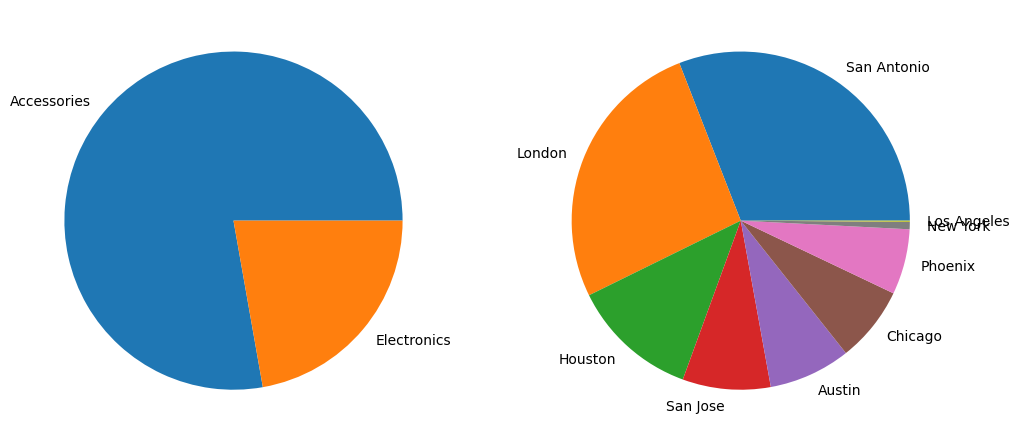

In [27]:
### Compare Sales by Category and Sales by Location

dfCat = df['category'].value_counts()
dfCity = df[['location', 'sales_total']]


sales_city = dfCity.sales_total
sales_cat = dfCat.values
cat = dfCat.index
loc = dfCity.location

fig, (ax0, ax1) = plt.subplots(1, 2, figsize = (12, 6))

ax0.pie(sales_cat, labels=cat)
ax1.pie(sales_city, labels=loc)

plt.show()
plt.close()

In [28]:
%pip install folium


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [29]:
# 1. Initialize an empty Python list (like an empty array)
sales_data = []

# 2. Loop through the DataFrame row by row
for index, row in df.iterrows():
    # Extract the values from the specific columns for this row
    city = row['location']
    sales = row['sales_total']
    
    # Bundle them into a tuple (pair) and append to our list
    sales_data.append((city, sales))

In [30]:
import folium
import branca.colormap as cm
from branca.element import Element

#  Initialize an empty Python list (like an empty array)
sales_data = []

#  Loop through the DataFrame row by row
for index, row in df.iterrows():
    # Extract the values from the specific columns for this row
    city = row['location']
    sales = row['sales_total']
    
    # Bundle them into a tuple (pair) and append to our list
    sales_data.append((city, sales))
    
geo_coords = {
    "San Antonio": (29.4241, -98.4936),
    "London": (51.5074, -0.1278),
    "Houston": (29.7604, -95.3698),
    "San Jose": (37.3382, -121.8863),
    "Austin": (30.2672, -97.7431),
    "Chicago": (41.8781, -87.6298),
    "Phoenix": (33.4484, -112.0740),
    "New York": (40.7128, -74.0060),
    "Los Angeles": (34.0522, -118.2437)
}

# Create a custom HTML/CSS block for the title
title_html = '''
             <h3 align="center" style="font-size:22px; 
                                       font-family: Arial, sans-serif;
                                       font-weight: bold;
                                       position: fixed; 
                                       top: 10px; 
                                       left: 50%; 
                                       transform: translateX(-50%);
                                       z-index:9999; 
                                       background-color: rgba(255, 255, 255, 0.85);
                                       padding: 10px 20px;
                                       border-radius: 8px;
                                       box-shadow: 0px 2px 5px rgba(0,0,0,0.2);
                                       margin: 0;">
                 Sales Performance by City
             </h3>
             '''

# Dynamically find the min and max sales to scale the colorbar bounds
all_sales = [sales for city, sales in sales_data]
min_sales = min(all_sales)
max_sales = max(all_sales)

# Define the Continuous Colorbar (Blue for Small/Low, Red for Big/High)
# 'vmin' and 'vmax' act like your lower and upper boundaries
colormap = cm.LinearColormap(
    colors=['blue', 'red'], 
    vmin=min_sales, 
    vmax=max_sales, 
    caption='Total Sales Performance ($)'
)

# 3.  Centered in the middle of the Atlantic Ocean so both US and UK cities display nicely
data_map = folium.Map(location=[40.0, -50.0], zoom_start=3)


# 4. Scaling Function
# Scales the circle radius so larger sales stand out without taking over the map
def get_radius(sales):
    base_scale = 0.003  # Tweak this multiplier to change overall bubble sizes
    min_radius = 5       # Ensures low-performing cities stay visible
    return max(sales * base_scale, min_radius)


# Inject the HTML element directly into the map document body
data_map.get_root().html.add_child(Element(title_html))


#  Populate the Map
for city, total_sales in sales_data:
    # Check if the city exists in our GPS dictionary to avoid key errors
    if city in geo_coords:
        coords = geo_coords[city]
        
        # Create a formatted popup window
        popup_text = f"<strong>{city}</strong><br>Total Sales: ${total_sales:,.2f}"
        
        # Determine the dynamic hex color string using our colormap lookup
        dynamic_color = colormap(total_sales)
        
        # Add the bubble marker to the map
        folium.CircleMarker(
            location=coords,
            radius=get_radius(total_sales),
            popup=folium.Popup(popup_text, max_width=200),
            color=dynamic_color,        # Dynamic border color
            fill=True,
            fill_color=dynamic_color,   # Dynamic bubble color
            fill_opacity=0.6,
            weight=1.5
        ).add_to(data_map)
        

data_map

In [31]:
# Check for transaction records where customer_id IS NULL

start_time = time.time()

query = """


WITH Product_Info AS (

    SELECT
        product_id,
        category,
        product_name,
        price
    FROM Product_Details
    GROUP BY product_id

),

Sales_Info AS (

    SELECT
        s.transaction_id,
        s.customer_id,
        s.product_id,
        p.category,
        p.product_name,
        p.price,
        s.quantity,
        s.sale_date,
        s.total_amount

    FROM Sales_Transactions AS s

    LEFT JOIN Product_Info AS p
        ON p.product_id = s.product_id

),

Customer_Info AS (

    SELECT
        c.location,
        c.customer_id,
        c.age,
        c.gender

    FROM Customer_Demographics AS c
    GROUP BY customer_id

),

Full_Table AS (

    SELECT
        s.transaction_id,
        s.customer_id,
        s.product_id,
        s.category,
        s.product_name,
        s.quantity,
        s.price,
        c.location,
        c.age,
        c.gender,
        s.sale_date,
        s.total_amount

    FROM Sales_Info AS s

    LEFT JOIN Customer_Info AS c
        ON c.customer_id = s.customer_id


      WHERE s.price IS NOT NULL

    GROUP BY s.transaction_id

)

SELECT
    customer_id,
    location,
    category,
    SUM(quantity * price) AS sales_total,
    SUM(total_amount) AS totalAmount

FROM Full_Table

GROUP BY location

ORDER BY sales_total DESC, location;

"""

df = pd.read_sql_query(query, conn)
end_time = time.time()
print(f"Query execution time: {end_time - start_time} seconds")
display(df)

Query execution time: 0.029819965362548828 seconds


,customer_id,location,category,sales_total,totalAmount
0,5.0,San Antonio,Electronics,13225,1480.0
1,13.0,London,Accessories,11275,650.0
2,15.0,Houston,Accessories,5200,330.0
3,NaN,None,Electronics,3675,220.0
4,55.0,San Jose,Accessories,3600,350.0
5,3.0,Austin,Accessories,3350,270.0
6,37.0,Chicago,Accessories,3100,240.0
7,46.0,Phoenix,Electronics,2675,290.0
8,42.0,New York,Accessories,300,150.0
9,35.0,Los Angeles,Accessories,50,40.0


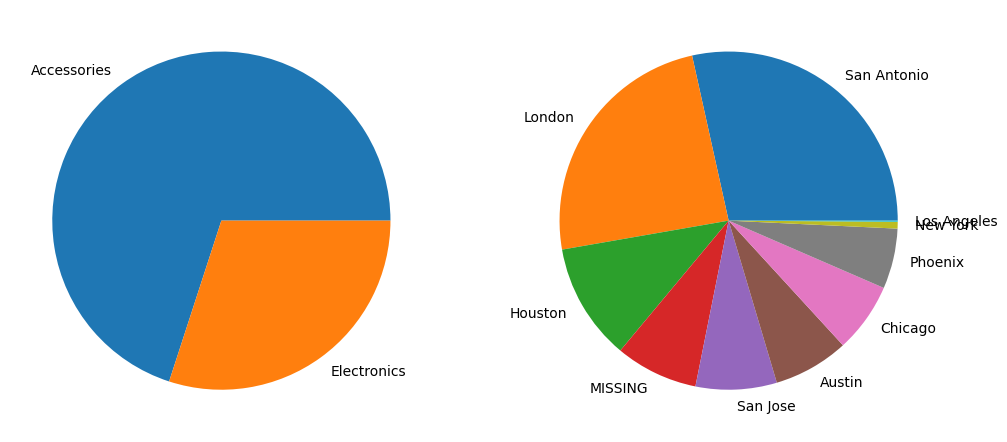

In [32]:
### Compare Sales by Category and Sales by Location Including cusotmer_id=NULL)

dfCat = df['category'].value_counts()
dfCity = df[['location', 'sales_total']]


sales_city = dfCity.sales_total
sales_cat = dfCat.values
cat = dfCat.index
loc = dfCity.location
loc = loc.fillna('MISSING')

fig, (ax0, ax1) = plt.subplots(1, 2, figsize = (12, 6))

ax0.pie(sales_cat, labels=cat)
ax1.pie(sales_city, labels=loc)

plt.show()
plt.close()

# Activity 4: Generating the Analysis Report  

Now that we've performed our analysis, it's time to compile our findings into a comprehensive report.

## Step 1:
<b>Summarize key findings:</b>
- List the top 3 insights from your analysis
- Provide supporting data for each insight

## Step 2:
<b>Include SQL queries:</b>
- For each key insight, provide the SQL query used

## Step 3:
<b>Document your process:</b>
- Explain your data cleaning steps
- Describe any challenges you encountered and how you overcame them
- Discuss potential areas for further analysis

## Close the Connection
It's good practice to close the database connection when you're done

In [33]:
# Close the database connection 
conn.close()

## ✅ Success Checklist
- Cleaned and prepared all dataset tables
- Performed at least 3 advanced SQL queries using subqueries, CTEs, or window functions
- Optimized at least one complex query for better performance
- Compiled a comprehensive analysis report with key insights and supporting data
- Program runs without errors

## 🔍 Common Issues & Solutions 

- Problem: Query returns no results 
    - Solution: Double-check table and column names, and ensure your JOIN conditions are correct
- Problem: Error "no such table" 
     - Solution: Verify that you're connected to the correct database and that the table name is spelled correctly

## ➡️ Summary
In this comprehensive lab, you've applied advanced SQL concepts to analyze TechMart's retail operations data, working with multiple related tables covering employee records, product details, customer demographics, and sales transactions. You've gained hands-on experience in data cleaning, writing complex queries using subqueries, CTEs, and window functions, and optimizing query performance through indexing. Through this real-world simulation, you've developed the practical skills needed to conduct thorough data analysis and create well-documented reports, preparing you for actual data science roles.


### 🔑 Key Points
- Data cleaning is crucial for accurate analysis
- Advanced SQL techniques like CTEs and window functions enable complex analysis
- Query optimization is essential for working with large datasets
- Effective reporting is key to communicating insights